# Homework 4: The Bootstrap

BEE 4850/5850, Fall 2025

**Name**: Liying Ma

**ID**: Lm698

> **Due Date**
>
> Friday, 3/28/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice simulation-based
uncertainty quantification, focusing on the bootstrap.

-   Problem 1 asks you to use the non-parametric bootstrap to estimate
    uncertainty in a Poisson regression model.
-   Problem 2 asks you to use the bootstrap (through resampling
    residuals) to estimate uncertainty in a semi-empirical sea-level
    rise model.
-   Problem 3 (only required for students in BEE 5850) asks you to use a
    moving block bootstrap to estimate the sampling distribution of the
    median of extreme water level data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4850/HW/hw04-LM698`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Revisit the salamander model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html), using
percent groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

**In this problem**:

-   Load the data from `data/salamanders.csv`.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Use 1,000 non-parametric bootstrap samples to obtain estimates of
    bias and the 90% confidence interval for the intercept and
    coefficient in the Poisson regression.

In [3]:
# Load Data and standarize
df = CSV.read("/Users/liyingma/BEE4850/HW/hw04-LM698/salamanders.csv", DataFrame)

function standardize(x)
    return (x .- mean(x)) ./ std(x)
end

standardize (generic function with 1 method)

In [4]:
# Define the Poisson log-likelihood function (Source: HW2)
function salamander_model(params, salamander_counts, pctcover)
    β₀, β₁ = params
    λ = exp.(β₀ * pctcover .+ β₁)
    loglik = sum(logpdf.(Poisson.(λ), salamander_counts))
    return loglik 
end

x_std = standardize(df."PCTCOVER")
y = df."SALAMAN"

# Define bounds and initial values for the parameters
lb = [-10.0, -50.0]
ub = [10.0, 50.0]
init = [0.0, 0.0]

optim_out = optimize(p -> -salamander_model(p, y, x_std), lb, ub, init)
θ_mle = optim_out.minimizer

@show round.(θ_mle; digits=3)

round.(θ_mle; digits = 3) = [1.16, 0.43]


2-element Vector{Float64}:
 1.16
 0.43

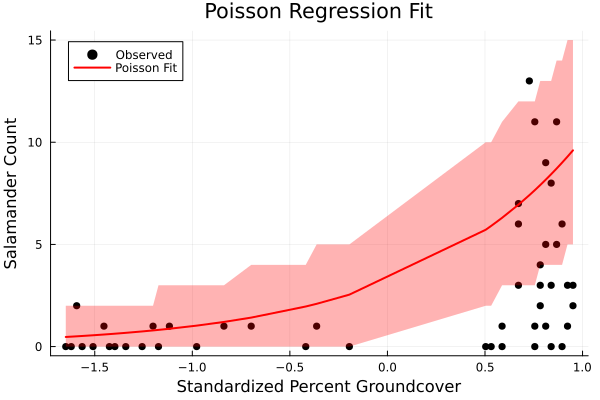

In [5]:
# Plot the fit
x_fit = sort(x_std)
λ_fit = exp.(θ_mle[1] .* x_fit .+ θ_mle[1])

# Scatter actual data
scatter(x_std, y, label="Observed", xlabel="Standardized Percent Groundcover", 
        ylabel="Salamander Count", title="Poisson Regression Fit", color=:black)

# Interval bounds using Poisson quantiles
lower = quantile.(Poisson.(λ_fit), 0.05)
upper = quantile.(Poisson.(λ_fit), 0.95)

plot!(x_fit, λ_fit, ribbon=(λ_fit .- lower, upper .- λ_fit), 
      color=:red, label="Poisson Fit", fillalpha=0.3, linewidth=2)

In [6]:
function fit_poisson(x_std, y)
    obj_fun = θ -> -salamander_model(θ, y, x_std)
    result = optimize(obj_fun, [-10.0, -50.0], [10.0, 50.0], [0.0, 0.0])
    return Optim.minimizer(result)
end

# Bootstrap
n_boot = 1000
n = length(y)
bootstrap_estimates = zeros(n_boot, 2)
Random.seed!(42)

for i in 1:n_boot
    sample_idx = rand(1:n, n)
    x_boot = x_std[sample_idx]
    y_boot = y[sample_idx]
    θ_boot = fit_poisson(x_boot, y_boot)
    bootstrap_estimates[i, :] .= θ_boot
end

# Bias
bias = mean(bootstrap_estimates, dims=1) - θ_mle'

# 90% CI
ci_lower = mapslices(x -> quantile(x, 0.05), bootstrap_estimates; dims=1)
ci_upper = mapslices(x -> quantile(x, 0.95), bootstrap_estimates; dims=1)
conf_intervals = hcat(ci_lower', ci_upper')

# Show resuls
println("Bias of β₀: ", round.(bias[1]; digits=4))
println("Bias of β₁: ", round.(bias[2]; digits=4))
println("90% Confidence Intervals β₀:", round.(conf_intervals[1,:]; digits=4))
println("90% Confidence Intervals β₁:", round.(conf_intervals[2,:]; digits=4))

Bias of β₀: 0.0416
Bias of β₁: -0.0529
90% Confidence Intervals β₀:[0.8473, 1.6787]
90% Confidence Intervals β₁:[0.014, 0.7166]


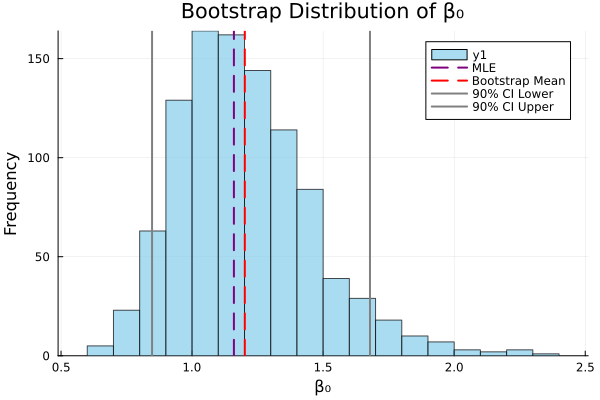

In [7]:
# Plotting function
function plot_bootstrap_distribution(samples, mle, param_name, ci)
    histogram(samples, bins=30, alpha=0.7, color=:skyblue, legend=:topright,
              xlabel=param_name, ylabel="Frequency", title="Bootstrap Distribution of $param_name")

    vline!([mle], color=:purple, linestyle=:dash, linewidth=2, label="MLE")
    vline!([mean(samples)], color=:red, linestyle=:dash, linewidth=2, label="Bootstrap Mean")
    vline!([ci[1]], color=:gray, linestyle=:solid, linewidth=2, label="90% CI Lower")
    vline!([ci[2]], color=:gray, linestyle=:solid, linewidth=2, label="90% CI Upper")
end

# Plot for β₀
plot_bootstrap_distribution(bootstrap_estimates[:, 1], θ_mle[1], "β₀", conf_intervals[1, :])

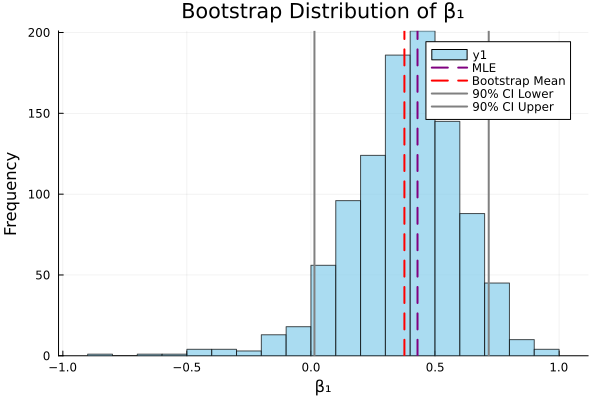

In [8]:
# Plot for β₁
plot_bootstrap_distribution(bootstrap_estimates[:, 2], θ_mle[2], "β₁", conf_intervals[2, :])

The bootstrap results shows that the original Poisson regression model has minimal bias, with the intercept slightly underestimated (bias = 0.0416) and the groundcover coefficient (slope) slightly overestimated (bias = -0.0529). The 90% confidence intervals show that the intercept (β₀) likely falls between 0.8473 and 1.6787, while the groundcover effect (β₁) ranges from 0.014 to 0.7166. Since the entire interval for β₁ is positive, this provides strong evidence that greater groundcover is associated with higher salamander counts. The small bias and narrow confidence intervals suggest the model's estimates are both accurate and precise.

### Problem 2

Revisit the sea-level rise model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html):

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

We would like to quantify uncertainty in the model parameters using the
bootstrap.

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data and
    include an initial sea-level parameter $S_0$. This will be similar
    to the model from Homework 2. Fit this model to the data with AR(1)
    residuals.
-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?

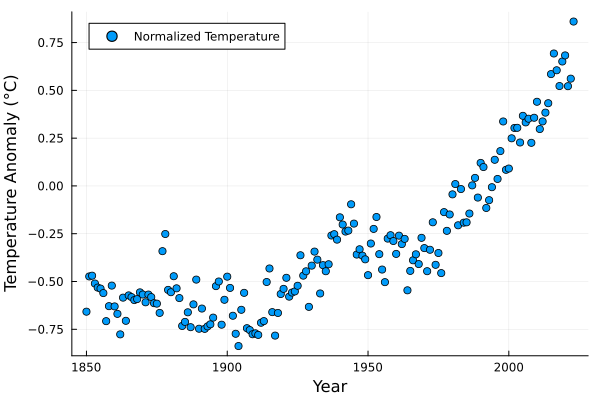

In [9]:
# Source: HW2
temp_df = CSV.read("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv", DataFrame)
sea_level_df = CSV.read("data/CSIRO_Recons_gmsl_yr_2015.csv", DataFrame)

# Adjust time in sea level dataset to match temp_df
sea_level_df[!, "Adjusted_Time"] = sea_level_df."Time" .- 0.5

# Find mean
temp_range = []
for i in 1:nrow(temp_df)
    if 1980 ≤ temp_df[i, "Time"] ≤ 1999
        push!(temp_range, temp_df[i, "Anomaly (deg C)"])
    end
end

sea_level_range = []
for i in 1:nrow(sea_level_df)
    if 1980 ≤ sea_level_df[i, "Adjusted_Time"] ≤ 1999
        push!(sea_level_range, sea_level_df[i, "GMSL (mm)"])
    end
end

# Compute means
temp_mean = mean(temp_range)
sea_level_mean = mean(sea_level_range)

# Normalize data
temp_df."Normalized Anomaly (deg C)" = temp_df."Anomaly (deg C)" .- temp_mean
sea_level_df."Normalized GMSL (mm)" = sea_level_df."GMSL (mm)" .- sea_level_mean

scatter(temp_df."Time", temp_df."Normalized Anomaly (deg C)", label="Normalized Temperature", xlabel="Year", ylabel="Temperature Anomaly (°C)")

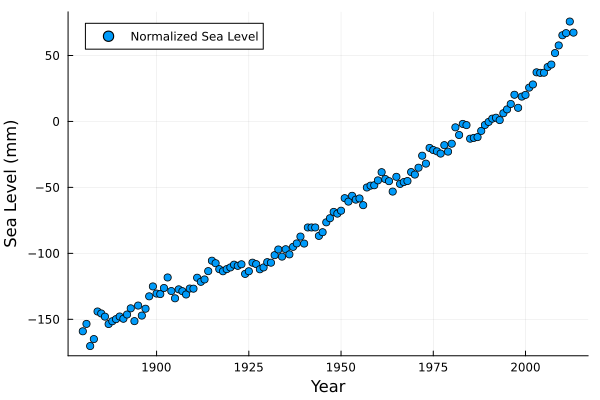

In [10]:
scatter(sea_level_df."Adjusted_Time", sea_level_df."Normalized GMSL (mm)", label="Normalized Sea Level", xlabel="Year", ylabel="Sea Level (mm)")

In [17]:
# Used HW2 answer key as Reference
# Define the common year range
common_years = 1880:2013

# Filter both datasets to keep only the common years
temp_subset = filter(row -> row."Time" in common_years, temp_df)
sea_level_subset = filter(row -> row."Adjusted_Time" in common_years, sea_level_df)

# Function to simulate sea level rise
function simulate_sea_level(T, a, b, tau, S0)
    S = zeros(length(T))
    S[1] = S0
    
    # Simulate sea level rise year by year
    for i in 2:length(T)
        S_eq = a * T[i] + b
            S[i] = S[i-1] + (S_eq - S[i-1]) *(1/tau)
    end
    return S[1:end]
end

# Function of AR(1)
function ar1_loglik_whitened(θ, T, S_obs)
    a, b, tau, S0, ρ, σ = θ
    S_model = simulate_sea_level(T, a, b, tau, S0)
    residuals = S_obs .- S_model

    if abs(ρ) >= 1 || σ <= 0
        return Inf
    end

    ll = 0.0
    for t in 1:length(residuals)
        if t == 1
            ll += logpdf(Normal(0, sqrt(σ^2 / (1 - ρ^2))), residuals[t])
        else
            ll += logpdf(Normal(ρ * residuals[t-1], σ), residuals[t])
        end
    end
    return -ll
end

initial_guess = [500.0, 770.0, 200.0, -157.0, 0.8, 5.0]  # a, b, tau, S0, ρ, σ
lower_bounds = [100.0, 50.0, 50.0, -170.0, -0.99, 1e-3]
upper_bounds = [600.0, 1000.0, 500.0, -155, 0.99, 50.0]

T = temp_subset[!, "Normalized Anomaly (deg C)"]
S_obs = sea_level_subset[!, "Normalized GMSL (mm)"]

result = optimize(θ -> ar1_loglik_whitened(θ, T, S_obs),
                  lower_bounds, upper_bounds, initial_guess, Fminbox())

a_fit, b_fit, tau_fit, S0_fit, ρ_fit, σ_fit = Optim.minimizer(result)

println("a: ", round(a_fit, digits=3))
println("b: ", round(b_fit, digits=3))
println("tau: ", round(tau_fit, digits=3))
println("S0: ", round(S0_fit, digits=3))
println("Estimated AR(1) Coefficient (ρ): ", round(ρ_fit, digits=3))
println("Estimated Noise Std Dev (σ): ", round(σ_fit, digits=3))

a: 557.572
b: 420.131
tau: 183.684
S0: -157.775
Estimated AR(1) Coefficient (ρ): 0.521
Estimated Noise Std Dev (σ): 4.951


Residuals mean: -0.0026166928772271896, std: 5.8353575918113725


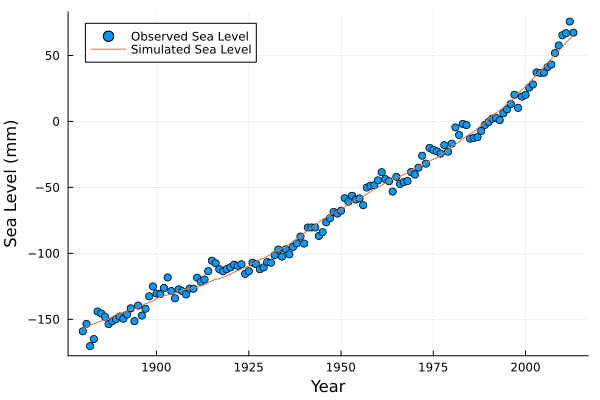

In [18]:
S_sim = simulate_sea_level(T, a_fit, b_fit, tau_fit, S0_fit)
residuals = sea_level_subset."Normalized GMSL (mm)" .- S_sim

# Results
println("Residuals mean: $(mean(residuals)), std: $(std(residuals))")

# Plot results
scatter(temp_subset.Time, sea_level_subset."Normalized GMSL (mm)", label="Observed Sea Level", xlabel="Year", ylabel="Sea Level (mm)", legend=:topleft)
plot!(temp_subset.Time, S_sim, label="Simulated Sea Level")

In [13]:
# Bootstrap
n_boot = 1000
boot_params = zeros(n_boot, 6)  # store a, b, tau, S0, ρ, σ

T = temp_subset[!, "Normalized Anomaly (deg C)"]
S_model = simulate_sea_level(T, a_fit, b_fit, tau_fit, S0_fit)
Random.seed!(42)

for i in 1:n_boot
    # Simulate AR(1) residuals
    r = zeros(length(T))
    r[1] = rand(Normal(0, sqrt(σ_fit^2 / (1 - ρ_fit^2))))
    for t in 2:length(T)
        r[t] = ρ_fit * r[t-1] + rand(Normal(0, σ_fit))
    end

    # Generate synthetic observed sea level data
    S_boot = S_model .+ r

    # Refit the model to the synthetic data
    result = optimize(θ -> ar1_loglik_whitened(θ, T, S_boot),
        lower_bounds, upper_bounds, initial_guess, Fminbox())

    # Save estimated parameters
    boot_params[i, :] = Optim.minimizer(result)
end


Parameter: a
  Bootstrap mean      = 519.374
  Basic CI lower bound = 515.145
  Basic CI upper bound = 756.904
Parameter: b
  Bootstrap mean      = 375.983
  Basic CI lower bound = 324.014
  Basic CI upper bound = 658.716
Parameter: tau
  Bootstrap mean      = 164.532
  Basic CI lower bound = 132.873
  Basic CI upper bound = 289.451
Parameter: S₀
  Bootstrap mean      = -158.221
  Basic CI lower bound = -160.551
  Basic CI upper bound = -153.252
Parameter: ρ
  Bootstrap mean      = 0.477
  Basic CI lower bound = 0.442
  Basic CI upper bound = 0.693
Parameter: σ
  Bootstrap mean      = 4.856
  Basic CI lower bound = 4.534
  Basic CI upper bound = 5.524


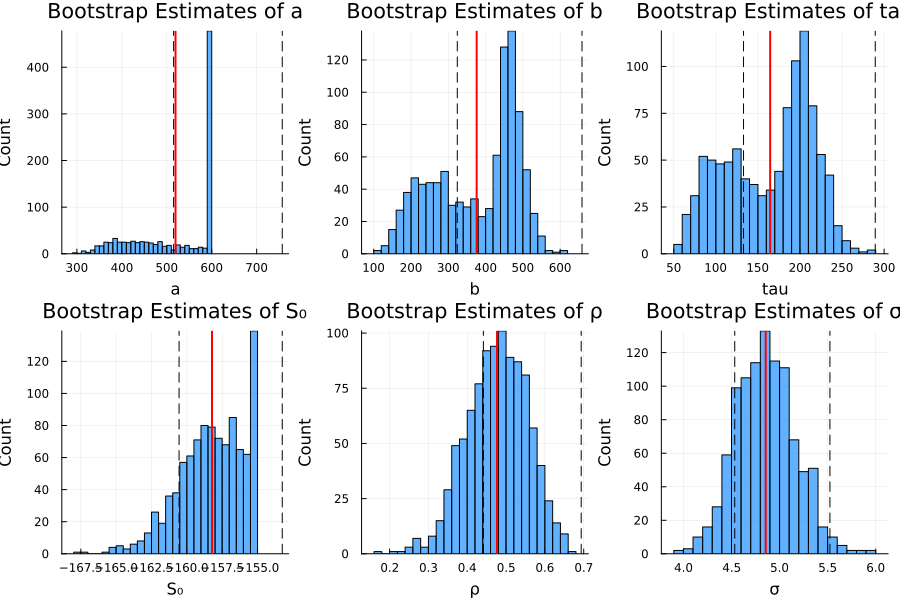

In [27]:
param_names = ["a", "b", "tau", "S₀", "ρ", "σ"]
θ_hat = [a_fit, b_fit, tau_fit, S0_fit, ρ_fit, σ_fit]
n_params = length(param_names)

plot_list = []

for j in 1:n_params
    samples = boot_params[:, j]
    t_hat = θ_hat[j]
    q = quantile(samples, [0.05, 0.95])
    ci_basic = [2t_hat - q[2], 2t_hat - q[1]]
    mean_boot = mean(samples)

    # Print summary
    println("Parameter: ", param_names[j])
    println("  Bootstrap mean      = ", round(mean_boot, digits=3))
    println("  Basic CI lower bound = ", round(ci_basic[1], digits=3))
    println("  Basic CI upper bound = ", round(ci_basic[2], digits=3))

    # Plot histogram
    p = histogram(
        samples,
        bins=30,
        title="Bootstrap Estimates of " * param_names[j],
        xlabel=param_names[j],
        ylabel="Count",
        label="",
        legend=false,
        linecolor=:black,
        fillalpha=0.7,
        color=:dodgerblue
    )

    # Add vertical lines for bootstrap mean and CI
    vline!(p, [mean_boot], linewidth=2, color=:red, label="Bootstrap Estimate")
    vline!(p, ci_basic, linestyle=:dash, color=:black, label="Bootstrap CI")

    push!(plot_list, p)
end

# Display all plots
plot(plot_list..., layout=(2, 3), size=(900, 600))


In [19]:
# Compute a/tau
t_boot_est = boot_params[:, 1] ./ boot_params[:, 3] # Boostrap estimate
t_mle_est = a_fit / tau_fit  # MLE estimate
q = quantile(t_boot_est, [0.05, 0.95])
ci_basic = [2t_mle_est - q[2], 2t_mle_est - q[1]]
t_boot = mean(t_boot_est)
println("bootstrap mean of a/tau: ", round.(t_boot, digits=3))
println("Basic bootstrap CI for a/tau: ", round.(ci_basic, digits=3))

bootstrap mean of a/tau: 3.35
Basic bootstrap CI for a/tau: [1.372, 3.514]


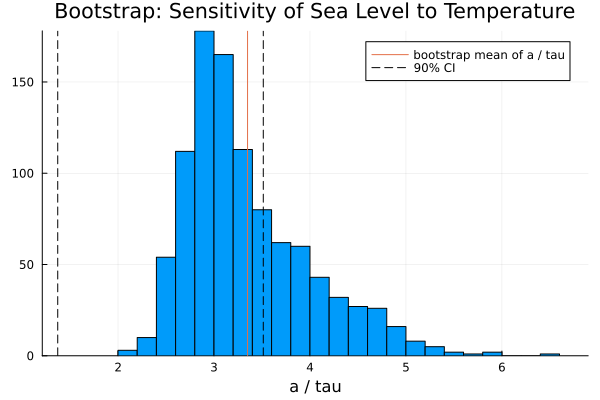

In [24]:
# Plot
histogram(t_boot_est, bins=30, xlabel="a / tau", label="", title="Bootstrap: Sensitivity of Sea Level to Temperature")
vline!([t_boot], label="bootstrap mean of a / tau")
vline!(ci_basic, label="90% CI", linestyle=:dash, color=:black)

The bootstrap results for the ratio a/τ shows insights about the short-term sea-level response to warming. With a mean value of 3.35 mm/(°C·yr) and a 90% confidence interval of [1.37, 3.51], this ratio indicates that each degree of global warming is expected to drive an initial sea-level rise of roughly 1.4 to 3.5 mm per year, even before the full equilibrium response is reached. The relatively narrow confidence interval, compared to the wider ranges seen for a and τ individually, suggests that uncertainties partially cancel out when considering their combined effect. The skewed CI suggests that extremely high short-term sensitivity is unlikely, but meaningful rise is still expected.